In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import os
import random
import matplotlib
import pandas as pd
from IPython.display import display, Image

In [2]:
import pandas as pd
import random
import osmnx as ox
import matplotlib.pyplot as plt

def generate_and_save_facilities(point, dist):
    """道路網から施設を生成し、CSVとして保存する関数。"""
    G = ox.graph_from_point(point, dist=dist, network_type="drive")
    nodes = G.nodes()
    node_points = list(nodes)

    hospital_points = random.sample(node_points, 5)
    supermarket_points = random.sample(node_points, 5)
    residence_points = random.sample(node_points, 50)

    hospitals = pd.DataFrame(
        {'name': [f"Hospital_{i+1}" for i in range(5)],
         'y': [nodes[node]['y'] for node in hospital_points],
         'x': [nodes[node]['x'] for node in hospital_points]}
    )
    supermarkets = pd.DataFrame(
        {'name': [f"Supermarket_{i+1}" for i in range(5)],
         'y': [nodes[node]['y'] for node in supermarket_points],
         'x': [nodes[node]['x'] for node in supermarket_points]}
    )
    residences = pd.DataFrame(
        {'name': [f"Residence_{i+1}" for i in range(50)],
         'y': [nodes[node]['y'] for node in residence_points],
         'x': [nodes[node]['x'] for node in residence_points]}
    )

    hospitals.to_csv('hospitals.csv', index=False)
    supermarkets.to_csv('supermarkets.csv', index=False)
    residences.to_csv('residences.csv', index=False)
    
    print("施設データがCSVファイルとして保存されました。")
    return hospitals, supermarkets, residences, G

if __name__ == '__main__':
    point = (35.568, 139.563)
    dist = 860
    hospitals, supermarkets, residences, G = generate_and_save_facilities(point, dist)
    
    # 施設のプロット（任意）
    fig, ax = ox.plot_graph(G, show=False, bgcolor='#FFFFFF')
    ax.set_title("Simulated Facilities around TCU Yokohama")
    ax.scatter(hospitals['x'], hospitals['y'], color='red', s=50, label='Hospital')
    ax.scatter(supermarkets['x'], supermarkets['y'], color='blue', s=50, label='Supermarket')
    ax.scatter(residences['x'], residences['y'], color='green', s=20, alpha=0.6, label='Residence')
    ax.legend()
    plt.savefig('tcu_map_facilities.png', dpi=300)
    plt.close(fig)
    print("地図画像が保存されました。")

施設データがCSVファイルとして保存されました。
地図画像が保存されました。


get_graph
Hospitals DataFrame:
         name          y           x
0  Hospital_1  35.568305  139.563967
1  Hospital_2  35.574724  139.571492
2  Hospital_3  35.573048  139.557357
3  Hospital_4  35.566810  139.568292
4  Hospital_5  35.574664  139.558111

Supermarkets DataFrame:
            name          y           x
0  Supermarket_1  35.563749  139.554058
1  Supermarket_2  35.562327  139.562436
2  Supermarket_3  35.572120  139.559325
3  Supermarket_4  35.562702  139.560528
4  Supermarket_5  35.565536  139.554908

Residences DataFrame:
            name          y           x
0    Residence_1  35.563713  139.557761
1    Residence_2  35.569413  139.564661
2    Residence_3  35.564505  139.566308
3    Residence_4  35.564532  139.554192
4    Residence_5  35.564408  139.555733
5    Residence_6  35.566533  139.565467
6    Residence_7  35.566168  139.563639
7    Residence_8  35.564937  139.569822
8    Residence_9  35.564450  139.562207
9   Residence_10  35.562960  139.556387
10  Residence_11  3

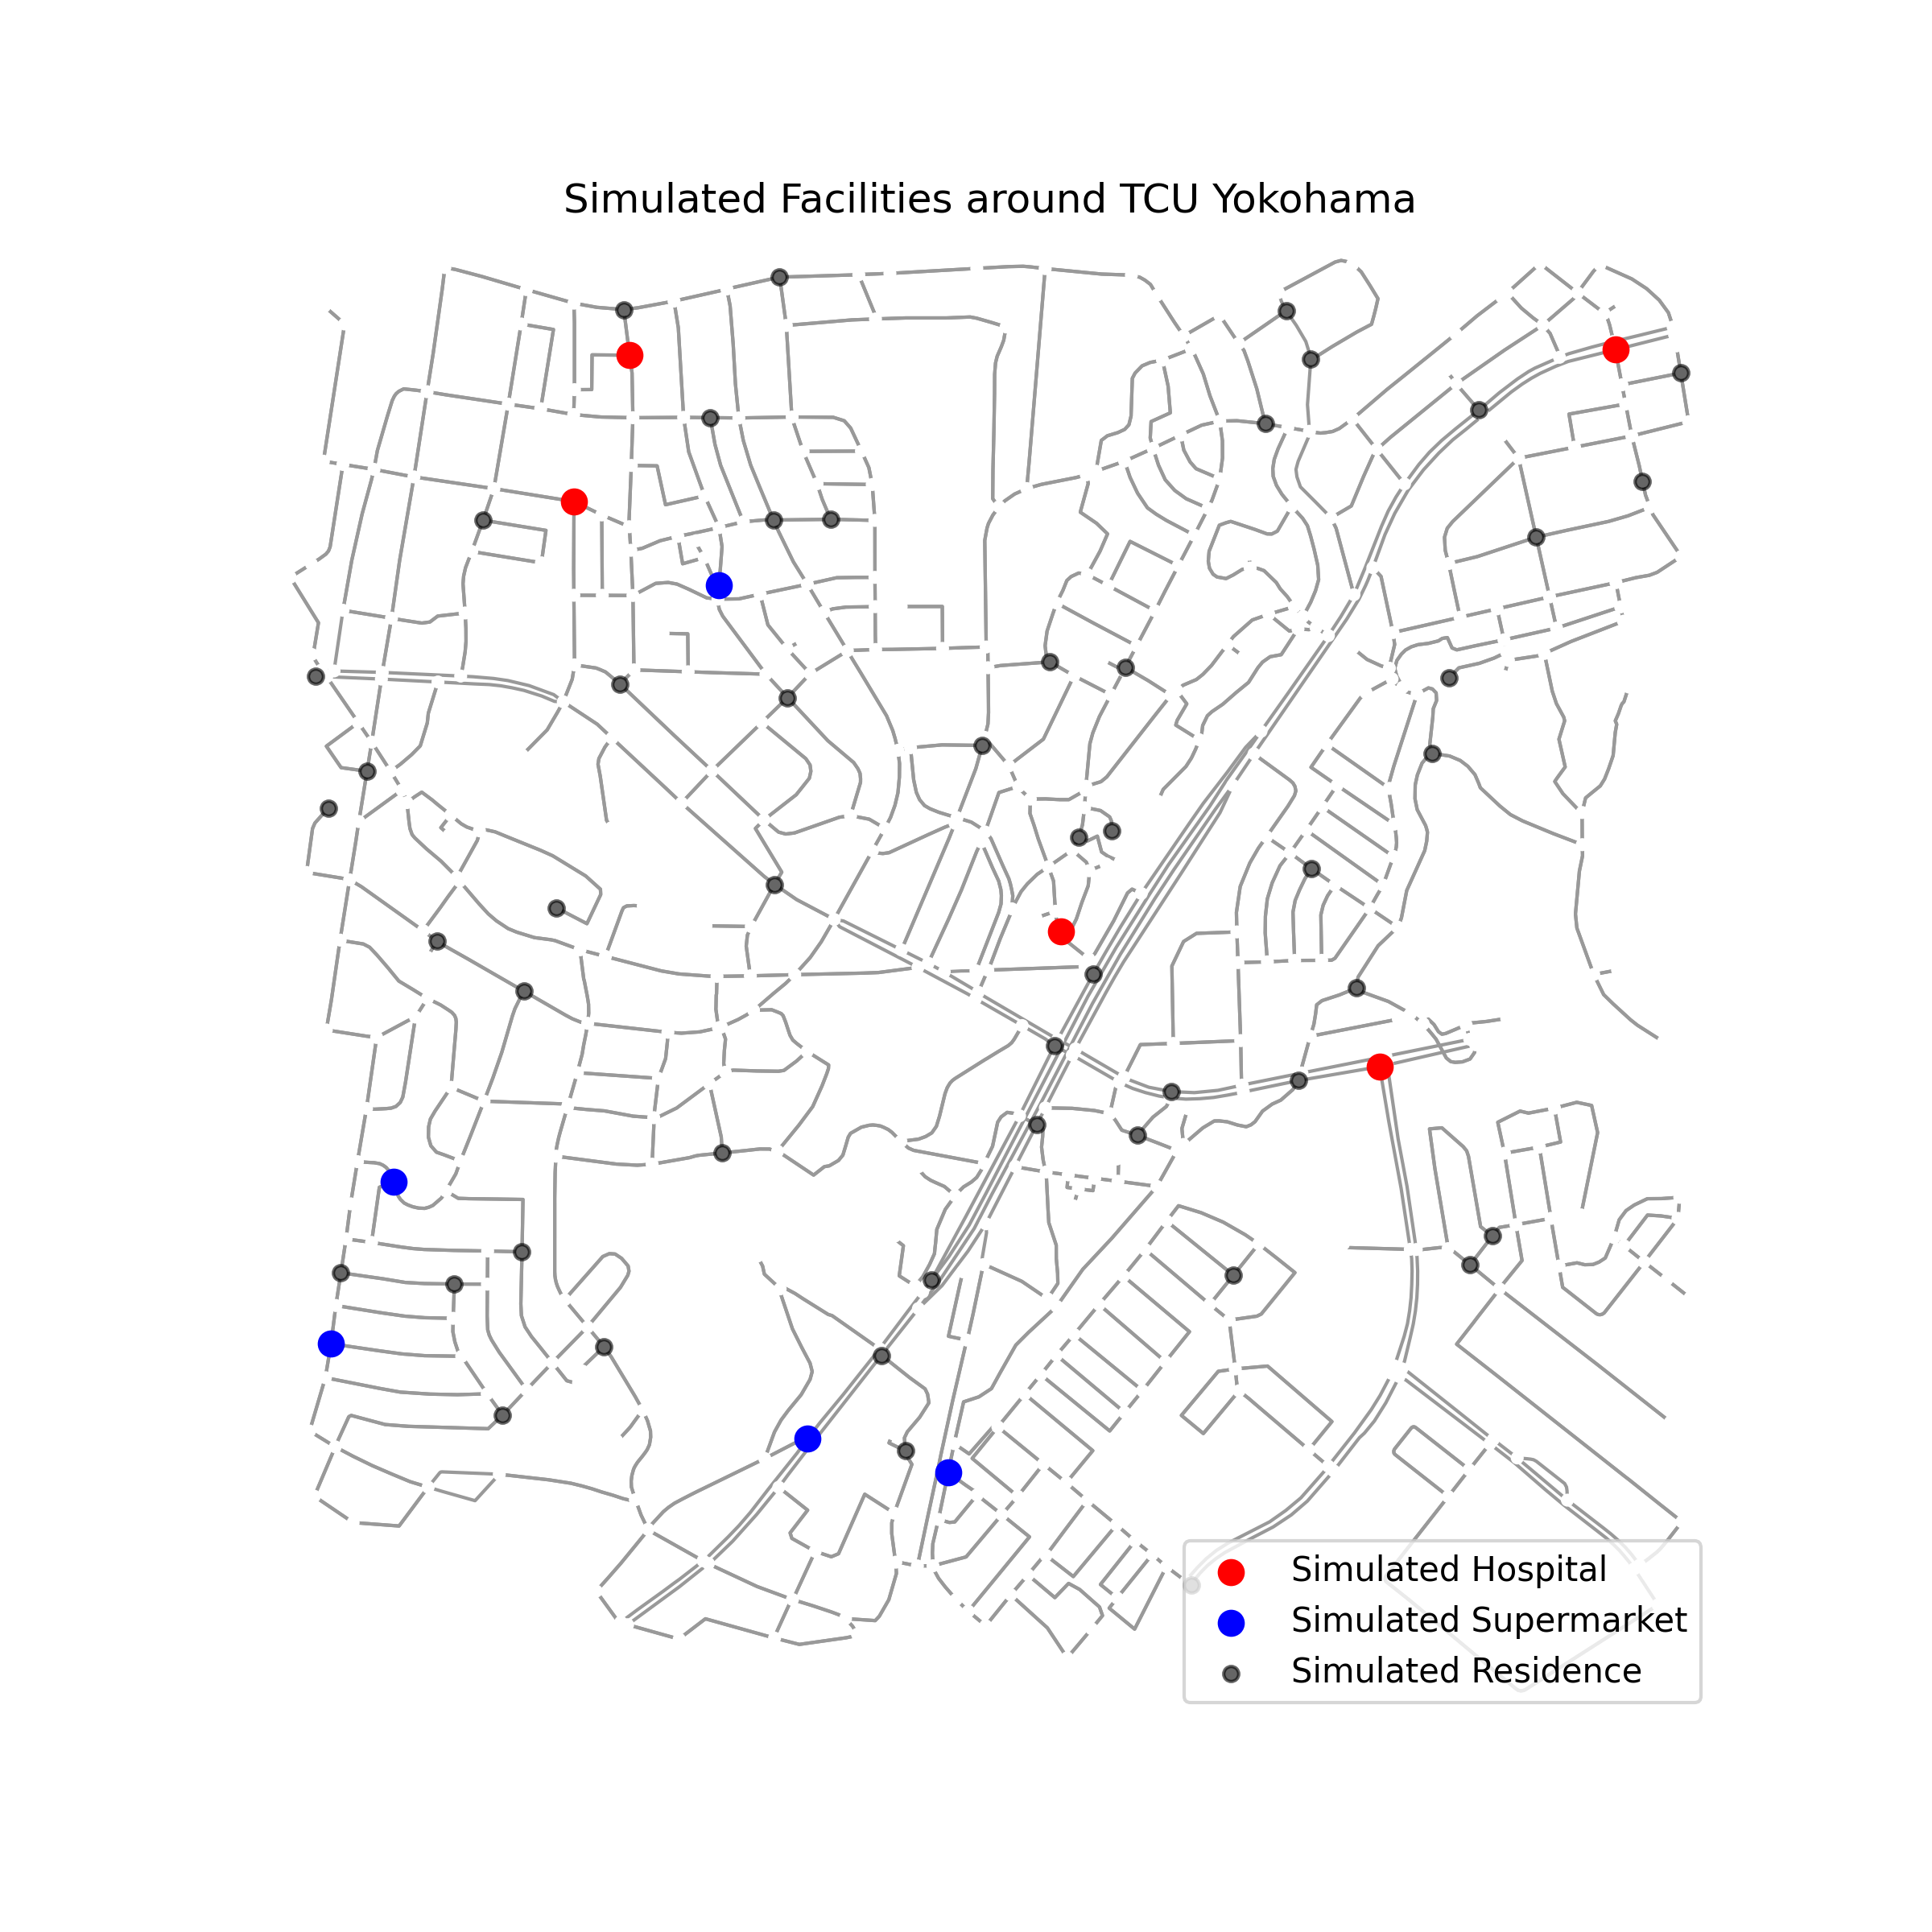

施設データがCSVファイルとして保存されました。


In [3]:
import pandas as pd
import random
import osmnx as ox
import matplotlib.pyplot as plt

# matplotlibのバックエンドをAggに設定
# この行は、実行環境によっては不要な場合があります
# plt.switch_backend('Agg')

# 東京都市大学 横浜キャンパスの緯度経度と、センター北駅までの距離（メートル）を指定
point = (35.568, 139.563) # 東京都市大学 横浜キャンパス
dist = 860 # 半径860メートル

# 道路網を取得
G = ox.graph_from_point(point, dist=dist, network_type="drive")
print("get_graph")

# 道路網の全てのノード（交差点）を取得
nodes = G.nodes()
node_points = list(nodes)

# ノードからランダムに10個の座標を選択
random_points = random.sample(node_points, 10)

# 最初の5つを病院、次の5つをスーパーとする
hospital_points = random_points[:5]
supermarket_points = random_points[5:]

# 病院に名前を付ける
hospital_names = [f"Hospital_{i+1}" for i in range(5)]
# スーパーマーケットに名前を付ける
supermarket_names = [f"Supermarket_{i+1}" for i in range(5)]

# プロット用のデータフレームを作成し、名前の列を追加
hospitals = pd.DataFrame(
    {'name': hospital_names,
     'y': [nodes[node]['y'] for node in hospital_points],
     'x': [nodes[node]['x'] for node in hospital_points]}
)
supermarkets = pd.DataFrame(
    {'name': supermarket_names,
     'y': [nodes[node]['y'] for node in supermarket_points],
     'x': [nodes[node]['x'] for node in supermarket_points]}
)

# ----------------- ここから追加されたコード -----------------

# 道路網のノードからランダムに50個の住宅ノードを選択
# 既存の病院・スーパーのノードと重複しないように、全ノードから改めて選択
residence_points = random.sample(node_points, 50)
residence_names = [f"Residence_{i+1}" for i in range(50)]

# 住宅用のデータフレームを作成
residences = pd.DataFrame(
    {'name': residence_names,
     'y': [nodes[node]['y'] for node in residence_points],
     'x': [nodes[node]['x'] for node in residence_points]}
)

# -------------------------------------------------------------

print("Hospitals DataFrame:")
print(hospitals)
print("\nSupermarkets DataFrame:")
print(supermarkets)
print("\nResidences DataFrame:")
print(residences)

# 描画の準備
fig, ax = ox.plot_graph(G, show=False, bgcolor='#FFFFFF')
ax.set_title("Simulated Facilities around TCU Yokohama")

# 病院を赤色でプロット
ax.scatter(hospitals['x'], hospitals['y'], color='red', s=50, label='Simulated Hospital')
# スーパーマーケットを青色でプロット
ax.scatter(supermarkets['x'], supermarkets['y'], color='blue', s=50, label='Simulated Supermarket')
# 住宅を緑色でプロット
ax.scatter(residences['x'], residences['y'], color='black', s=20, alpha=0.6, label='Simulated Residence')

# 凡例を表示
ax.legend()

# 描画した画像をファイルとして保存
plt.savefig('tcu_map_simulated_facilities_all.png', dpi=300)
print("map saved")

# ファイルを読み込んで表示
from IPython.display import Image, display
display(Image(filename='tcu_map_simulated_facilities_all.png'))

# 描画ウィンドウを閉じる
plt.close(fig)

hospitals.to_csv('hospitals.csv', index=False)
supermarkets.to_csv('supermarkets.csv', index=False)
residences.to_csv('residences.csv', index=False)
print("施設データがCSVファイルとして保存されました。")